# 📈 Financial Analytics — Séries Temporais: Fundamentos e Modelagem SARIMA

**Autores:** Paloma Vaissman Uribe & Julio Trecenti  
**Instituição:** Insper — PADS  
**Ano:** 2026

---

Este notebook acompanha os slides da aula e contém todos os códigos para rodar interativamente.  
Execute as células em ordem — cada seção corresponde a uma parte dos slides.

### ⚙️ Instalação das dependências


In [1]:
# Execute esta célula PRIMEIRO (pode demorar ~1 min no Colab)
import subprocess, sys

pkgs = ['statsmodels', 'statsforecast']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("✅ Pacotes instalados!")
print("ℹ️  Os dados do BCB são carregados direto via API REST — sem dependências extras.")


✅ Pacotes instalados!
ℹ️  Os dados do BCB são carregados direto via API REST — sem dependências extras.


In [2]:
# Importações globais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Configuração visual — tema escuro compatível com os slides
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#1C1C1C',
    'axes.facecolor':   '#252525',
    'axes.edgecolor':   '#444444',
    'axes.labelcolor':  '#E8E8E8',
    'xtick.color':      '#AAAAAA',
    'ytick.color':      '#AAAAAA',
    'text.color':       '#E8E8E8',
    'grid.color':       '#333333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'figure.dpi':       110,
    'savefig.bbox':     'tight',
})

RED, BLUE, GREEN, GRAY, YELLOW = '#E4002B', '#4a9eff', '#2ecc71', '#aaaaaa', '#ffaa00'

print("✅ Pacotes importados com sucesso!")

✅ Pacotes importados com sucesso!


In [3]:
import requests
import pandas as pd

def bcb_serie(codigo, start='2003-01-01', end=None):
    """
    Baixa uma série do Banco Central via API REST.
    Não requer python-bcb — usa apenas requests (já presente no Colab).

    Parâmetros
    ----------
    codigo : int   Código da série no SGS/BCB
    start  : str   Data inicial no formato 'YYYY-MM-DD'
    end    : str   Data final  no formato 'YYYY-MM-DD' (opcional)

    Exemplos de séries
    ------------------
    24363  IBC-Br (proxy mensal do PIB)
    433    IPCA mensal
    11     Taxa Selic diária
    1      Câmbio USD/BRL diário
    24369  Taxa de desemprego mensal
    21859  Produção industrial mensal
    """
    # Converter datas para o formato dd/mm/aaaa exigido pela API
    di = pd.Timestamp(start).strftime('%d/%m/%Y')
    url = (f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
           f"?formato=json&dataInicial={di}")
    if end:
        df_str = pd.Timestamp(end).strftime('%d/%m/%Y')
        url += f"&dataFinal={df_str}"

    resp = requests.get(url, timeout=30)
    resp.raise_for_status()

    df = pd.DataFrame(resp.json())
    df['data']  = pd.to_datetime(df['data'], dayfirst=True)
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df = df.set_index('data').rename(columns={'valor': f'serie_{codigo}'})
    df = df.dropna()
    return df

print("✅ Função bcb_serie() definida!")
print()
print("Uso: df = bcb_serie(24363)  # IBC-Br")
print("     df = bcb_serie(433)    # IPCA")


✅ Função bcb_serie() definida!

Uso: df = bcb_serie(24363)  # IBC-Br
     df = bcb_serie(433)    # IPCA


---
## 🔴 Parte 1 — Fundamentos

### 1.1 · Variável Aleatória e Processo i.i.d.

Uma **variável aleatória** associa a cada resultado $\omega \in \Omega$ do espaço amostral um número real:
$$X: \Omega \to \mathbb{R}$$

**Exemplo:** ao jogar um dado não viciado, $\Omega = \{1,2,3,4,5,6\}$ e $P(X=k) = 1/6$.

Quando repetimos o lançamento $n$ vezes de forma **independente** e com a **mesma distribuição**, temos um processo **i.i.d.**.


In [4]:
# Simulação: 500 lançamentos de um dado de 6 faces
np.random.seed(42)
n = 500

def dados(n, k):
    """
    Gera uma amostra de 'n' pontos de dados,
    escolhidos de 1 a 'k' com reposição.
    """
    return np.random.randint(1, k + 1, size=n)

dados_gerados = dados(n, 6)

print(f"Primeiros 20 resultados: {dados_gerados[:20]}")
print(f"Média amostral:  {dados_gerados.mean():.3f}  (esperado: {3.5})")
print(f"Desvio padrão:   {dados_gerados.std():.3f}  (esperado: {np.sqrt(35/12):.3f})")

Primeiros 20 resultados: [4 5 3 5 5 2 3 3 3 5 4 3 6 5 2 4 6 6 2 4]
Média amostral:  3.500  (esperado: 3.5)
Desvio padrão:   1.721  (esperado: 1.708)


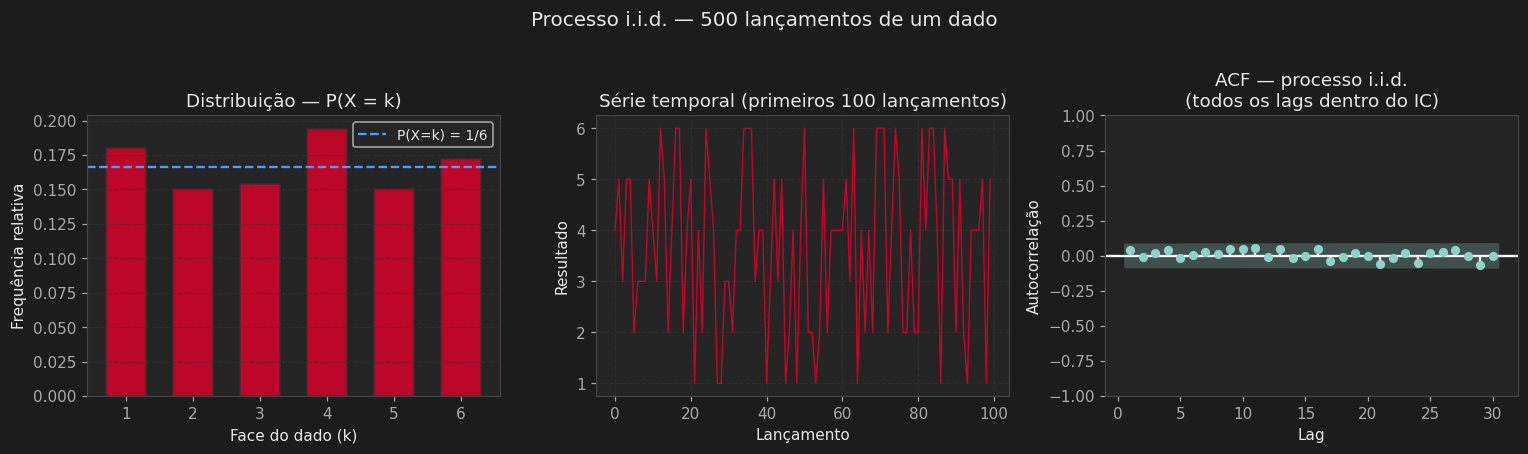


📊 Lags fora do IC 95%: 0/30  (por acaso, esperamos ~1-2)
✅ ACF limpa confirma: processo i.i.d., sem memória!


In [5]:
# Visualização: distribuição, série temporal e ACF
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Painel 1: distribuição empírica
counts = np.bincount(dados_gerados, minlength=7)[1:]
axes[0].bar(range(1, 7), counts / n, color=RED, alpha=0.8, width=0.6, edgecolor='#333')
axes[0].axhline(1/6, color=BLUE, linewidth=1.5, linestyle='--', label='P(X=k) = 1/6')
axes[0].set_title('Distribuição — P(X = k)')
axes[0].set_xlabel('Face do dado (k)')
axes[0].set_ylabel('Frequência relativa')
axes[0].set_xticks(range(1, 7))
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y')

# Painel 2: série temporal (primeiros 100)
axes[1].plot(dados_gerados[:100], color=RED, linewidth=0.9, alpha=0.85)
axes[1].set_title('Série temporal (primeiros 100 lançamentos)')
axes[1].set_xlabel('Lançamento')
axes[1].set_ylabel('Resultado')
axes[1].set_yticks(range(1, 7))
axes[1].grid(True)

# Painel 3: ACF — deve estar toda dentro das bandas
plot_acf(dados_gerados, ax=axes[2], lags=30, zero=False,
         title='ACF — processo i.i.d.\n(todos os lags dentro do IC)')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelação')

plt.suptitle('Processo i.i.d. — 500 lançamentos de um dado', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Conclusão
ci = 1.96 / np.sqrt(n)
from statsmodels.tsa.stattools import acf as acf_func
acf_vals = acf_func(dados_gerados, nlags=30)[1:]
fora = np.sum(np.abs(acf_vals) > ci)
print(f"\n📊 Lags fora do IC 95%: {fora}/30  (por acaso, esperamos ~1-2)")
print("✅ ACF limpa confirma: processo i.i.d., sem memória!")

### 1.2 · Carregando o IBC-Br

Usaremos o **IBC-Br** (BCB — código 24363) como série de referência ao longo de toda a aula.  
É o proxy mensal do PIB calculado pelo Banco Central.


In [6]:
# Carrega IBC-Br (BCB 24363) via API REST — funciona direto no Colab
ibc_raw = bcb_serie(24363, start='2003-01-01')
ibc_raw.columns = ['ibc']

# Garantir frequência mensal
ibc_raw.index = pd.to_datetime(ibc_raw.index)
try:
    ibc_raw.index.freq = 'MS'
except:
    ibc_raw = ibc_raw.asfreq('MS')

# Cópia de trabalho
ibc = ibc_raw.copy()

print(f"✅ IBC-Br carregado!")
print(f"   Período: {ibc.index[0].date()} → {ibc.index[-1].date()}")
print(f"   Observações: {len(ibc)}")
ibc.head()


✅ IBC-Br carregado!
   Período: 2003-01-01 → 2026-02-01
   Observações: 278


,ibc
data,
2003-01-01,67.09215
2003-02-01,68.84580
2003-03-01,72.15635
2003-04-01,71.30098
2003-05-01,69.98241


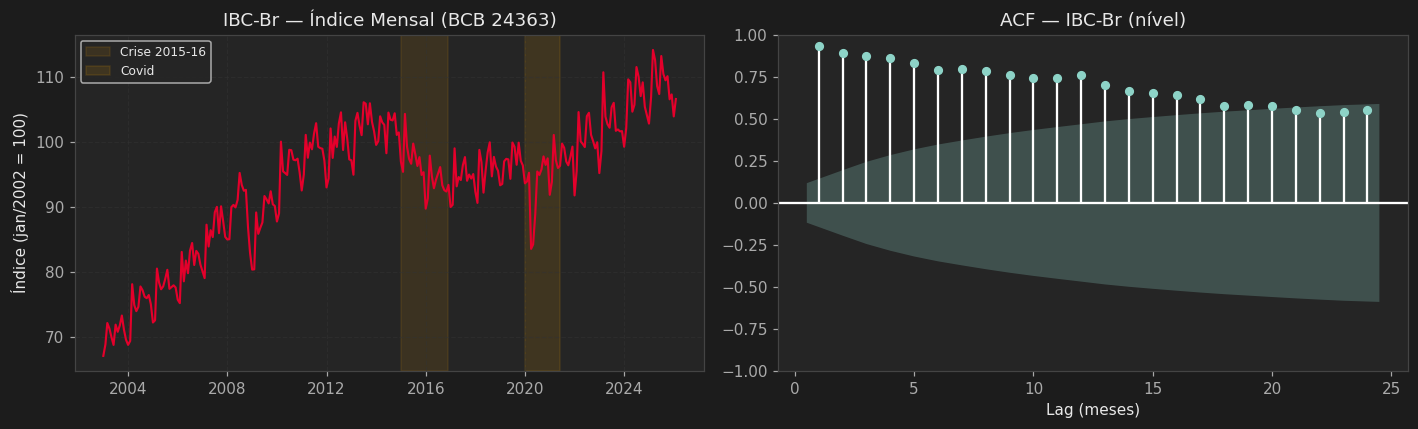


💡 A ACF decai muito lentamente → não-estacionariedade → raiz unitária!


In [7]:
# Série + ACF do nível
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ibc.index, ibc['ibc'], color=RED, linewidth=1.4)
axes[0].set_title('IBC-Br — Índice Mensal (BCB 24363)')
axes[0].set_ylabel('Índice (jan/2002 = 100)')
axes[0].grid(True)

# Destacar crises
axes[0].axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2016-12-01'),
                alpha=0.1, color='orange', label='Crise 2015-16')
axes[0].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
                alpha=0.12, color=YELLOW, label='Covid')
axes[0].legend(fontsize=8)

plot_acf(ibc['ibc'], ax=axes[1], lags=24, zero=False,
         title='ACF — IBC-Br (nível)')
axes[1].set_xlabel('Lag (meses)')

plt.tight_layout()
plt.show()

print("\n💡 A ACF decai muito lentamente → não-estacionariedade → raiz unitária!")

### 1.3 · Estacionariedade, Defasagem e Diferenciação

Um processo é **fracamente estacionário** quando média, variância e covariância são constantes no tempo.

- **Defasagem (lag):** $y_{t-k}$ — desloca a série no tempo
- **Diferenciação:** $\Delta y_t = y_t - y_{t-1}$ — remove tendência linear


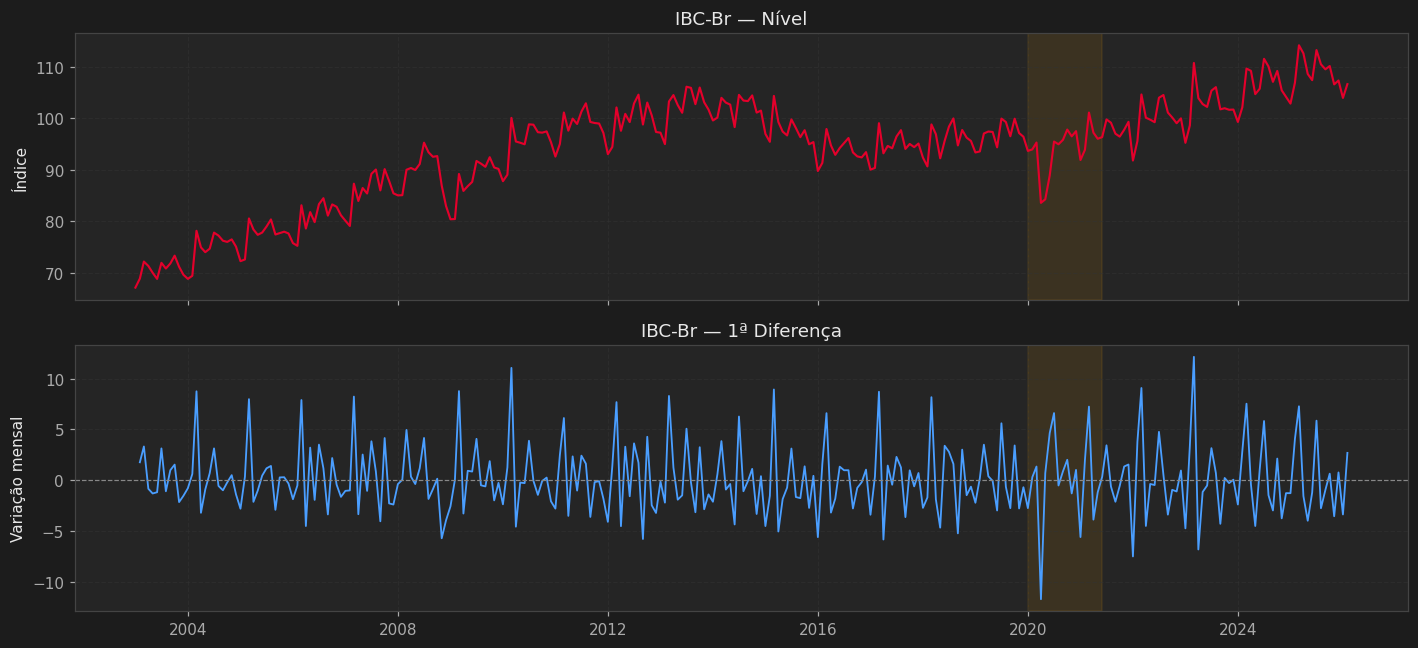

In [8]:
# Criar defasagem e primeira diferença
ibc['ibc_lag1'] = ibc['ibc'].shift(1)
ibc['ibc_diff'] = ibc['ibc'].diff(1)

# Visualizar nível vs diferença
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(ibc.index, ibc['ibc'], color=RED, linewidth=1.4)
axes[0].set_title('IBC-Br — Nível')
axes[0].set_ylabel('Índice')
axes[0].grid(True)

axes[1].plot(ibc.index, ibc['ibc_diff'], color=BLUE, linewidth=1.2)
axes[1].axhline(0, color='#888', linewidth=0.8, linestyle='--')
axes[1].set_title('IBC-Br — 1ª Diferença')
axes[1].set_ylabel('Variação mensal')
axes[1].grid(True)

# Sombra Covid
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
               alpha=0.1, color=YELLOW)

plt.tight_layout()
plt.show()

### 1.4 · Passeio Aleatório (*Random Walk*)

$$y_t = y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim RB(0, \sigma^2)$$

Quando $\phi = 1$ no AR(1), temos uma **raiz unitária**: choques se acumulam e a série "vagueia" sem retornar à média.


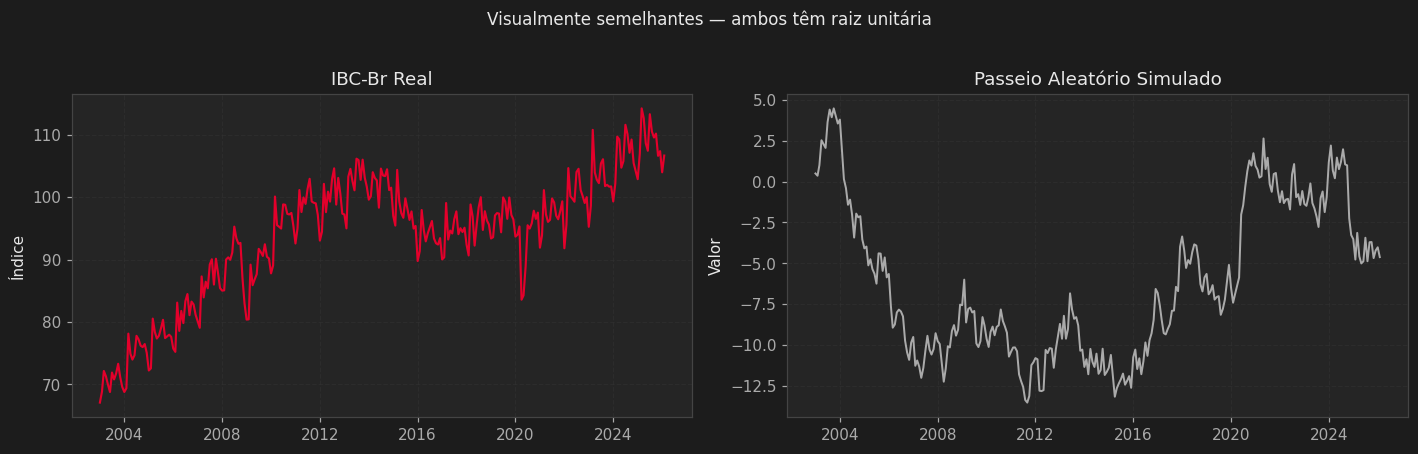

In [9]:
# Simulação de passeio aleatório
np.random.seed(42)
n_sim = len(ibc)
epsilon = np.random.normal(0, 1, n_sim)

rw = np.zeros(n_sim)
rw[0] = epsilon[0]
for i in range(1, n_sim):
    rw[i] = rw[i-1] + epsilon[i]

# Comparação visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ibc.index, ibc['ibc'], color=RED, linewidth=1.4)
axes[0].set_title('IBC-Br Real')
axes[0].set_ylabel('Índice')
axes[0].grid(True)

axes[1].plot(ibc.index, rw, color=GRAY, linewidth=1.3)
axes[1].set_title('Passeio Aleatório Simulado')
axes[1].set_ylabel('Valor')
axes[1].grid(True)

plt.suptitle('Visualmente semelhantes — ambos têm raiz unitária', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### 1.5 · Ruído Branco & Sazonalidade Residual

Um processo é **ruído branco** quando $\text{Cov}(\varepsilon_t, \varepsilon_s) = 0\ \forall\ t \neq s$.

Após a 1ª diferença, esperaríamos nos aproximar do ruído branco — mas veja o que acontece!


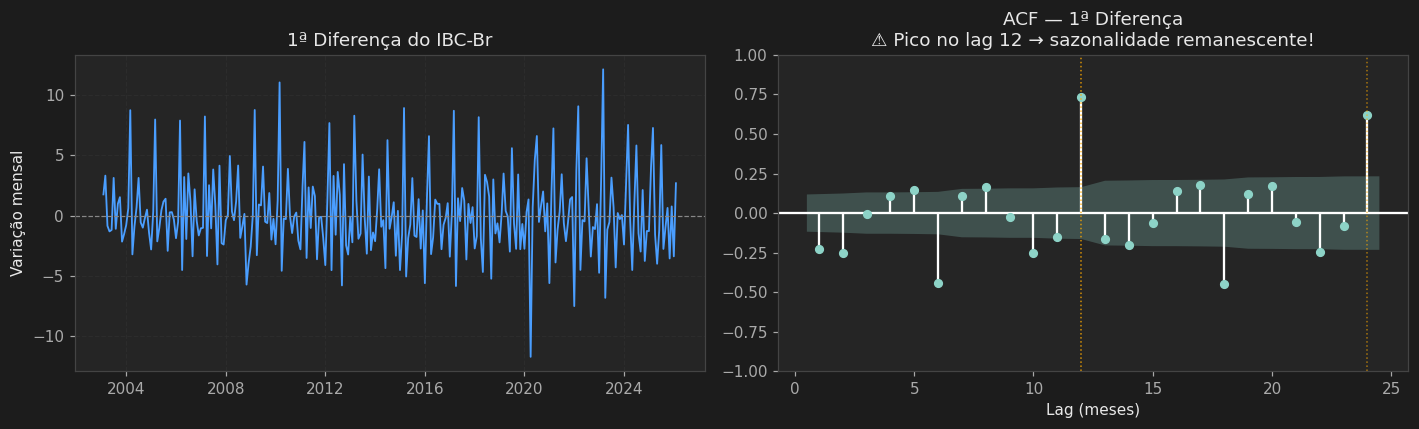

💡 Pico no lag 12 = sazonalidade anual não removida pela diff simples!
   → Precisamos de diferenciação SAZONAL (diff de ordem 12)


In [10]:
# ACF da 1ª diferença
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ibc.index[1:], ibc['ibc_diff'].dropna(), color=BLUE, linewidth=1.2)
axes[0].axhline(0, color='#888', linestyle='--', linewidth=0.8)
axes[0].set_title('1ª Diferença do IBC-Br')
axes[0].set_ylabel('Variação mensal')
axes[0].grid(True)

plot_acf(ibc['ibc_diff'].dropna(), ax=axes[1], lags=24, zero=False,
         title='ACF — 1ª Diferença\n⚠️ Pico no lag 12 → sazonalidade remanescente!')
axes[1].set_xlabel('Lag (meses)')

# Marcar lag 12
axes[1].axvline(12, color=YELLOW, linewidth=1, linestyle=':', alpha=0.8)
axes[1].axvline(24, color=YELLOW, linewidth=1, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("💡 Pico no lag 12 = sazonalidade anual não removida pela diff simples!")
print("   → Precisamos de diferenciação SAZONAL (diff de ordem 12)")

---
## 🔴 Parte 2 — Componentes, Decomposição e Teste ADF

### 2.1 · Diferenciação Sazonal + Dummy Covid

$$\Delta\Delta_{12} y_t = \Delta y_t - \Delta y_{t-12}$$

O Covid gerou um choque extremo que contamina a autocorrelação mesmo após a dupla diferenciação.  
Solução: **dummy** — tratar os meses afetados como valores ausentes (*missing*).


Meses removidos pela dummy: ['Jan/2020', 'Feb/2020', 'Mar/2020', 'Apr/2020', 'May/2020', 'Jun/2020']


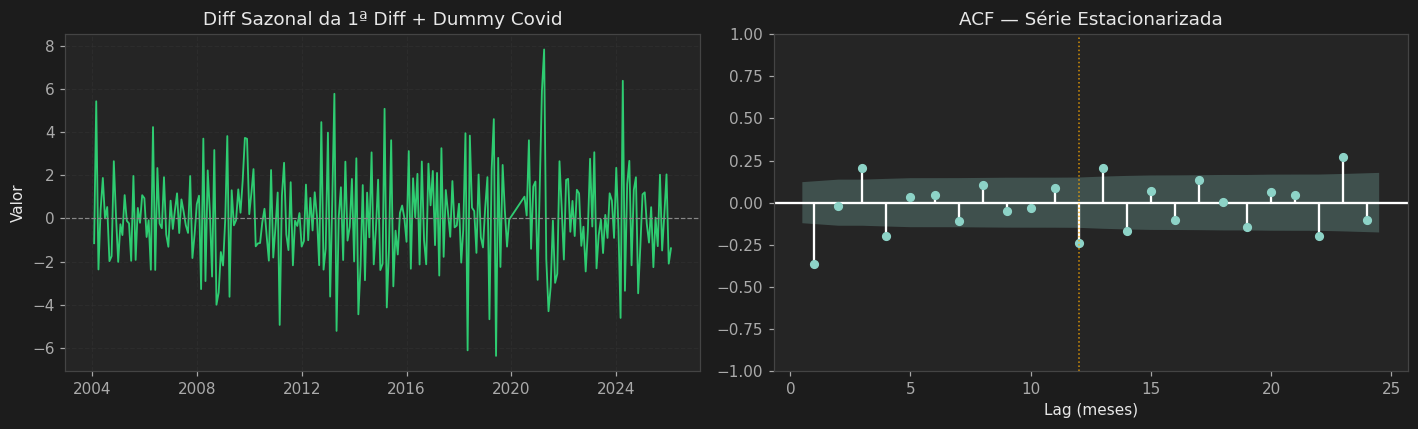


📊 Lags fora do IC: 10/24 | max ACF = 0.362 | IC = ±0.122
💡 Lag 12 residual → sazonalidade não-estável → motiva o termo SMA(1) no SARIMA!


In [11]:
# Diferença sazonal da 1ª diferença
ibc['ibc_diff_seas'] = ibc['ibc_diff'].diff(12)

# Dummy Covid: mar/2020 a ago/2020 como NaN
covid_idx = ibc.index[ibc.index >= '2020-01-01'][:6]
ibc.loc[covid_idx, 'ibc_diff_seas'] = np.nan

print(f"Meses removidos pela dummy: {list(covid_idx.strftime('%b/%Y'))}")

# Visualização: diff sazonal + ACF
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

serie_est = ibc['ibc_diff_seas'].dropna()
axes[0].plot(serie_est.index, serie_est.values, color=GREEN, linewidth=1.2)
axes[0].axhline(0, color='#888', linestyle='--', linewidth=0.8)
axes[0].set_title('Diff Sazonal da 1ª Diff + Dummy Covid')
axes[0].set_ylabel('Valor')
axes[0].grid(True)

plot_acf(serie_est, ax=axes[1], lags=24, zero=False,
         title='ACF — Série Estacionarizada')
axes[1].set_xlabel('Lag (meses)')
axes[1].axvline(12, color=YELLOW, linewidth=1, linestyle=':', alpha=0.8)

plt.tight_layout()
plt.show()

# Diagnóstico
from statsmodels.tsa.stattools import acf as acf_func
acf_vals = acf_func(serie_est, nlags=24)[1:]
ci = 1.96 / np.sqrt(len(serie_est))
fora = np.sum(np.abs(acf_vals) > ci)
print(f"\n📊 Lags fora do IC: {fora}/24 | max ACF = {np.max(np.abs(acf_vals)):.3f} | IC = ±{ci:.3f}")
print("💡 Lag 12 residual → sazonalidade não-estável → motiva o termo SMA(1) no SARIMA!")

### 2.2 · Componentes de uma Série Temporal

| Componente | O que é | Exemplo | Característica |
|---|---|---|---|
| **Tendência** | Movimento de longo prazo | IBC-Br crescendo décadas | Persistente, suave |
| **Sazonalidade** | Padrão em período fixo | Queda em jan (13º), alta em dez | Período constante |
| **Ciclo** | Flutuações de período variável | Expansão/recessão (3–10 anos) | Menos previsível |
| **Resíduo** | Variação após remover demais | Choque do Covid | Idealmente ruído branco |

**Modelo Aditivo:** $Y_t = T_t + S_t + C_t + R_t$  
**Modelo Multiplicativo:** $Y_t = T_t \times S_t \times R_t$ (use quando amplitude sazonal cresce com o nível)


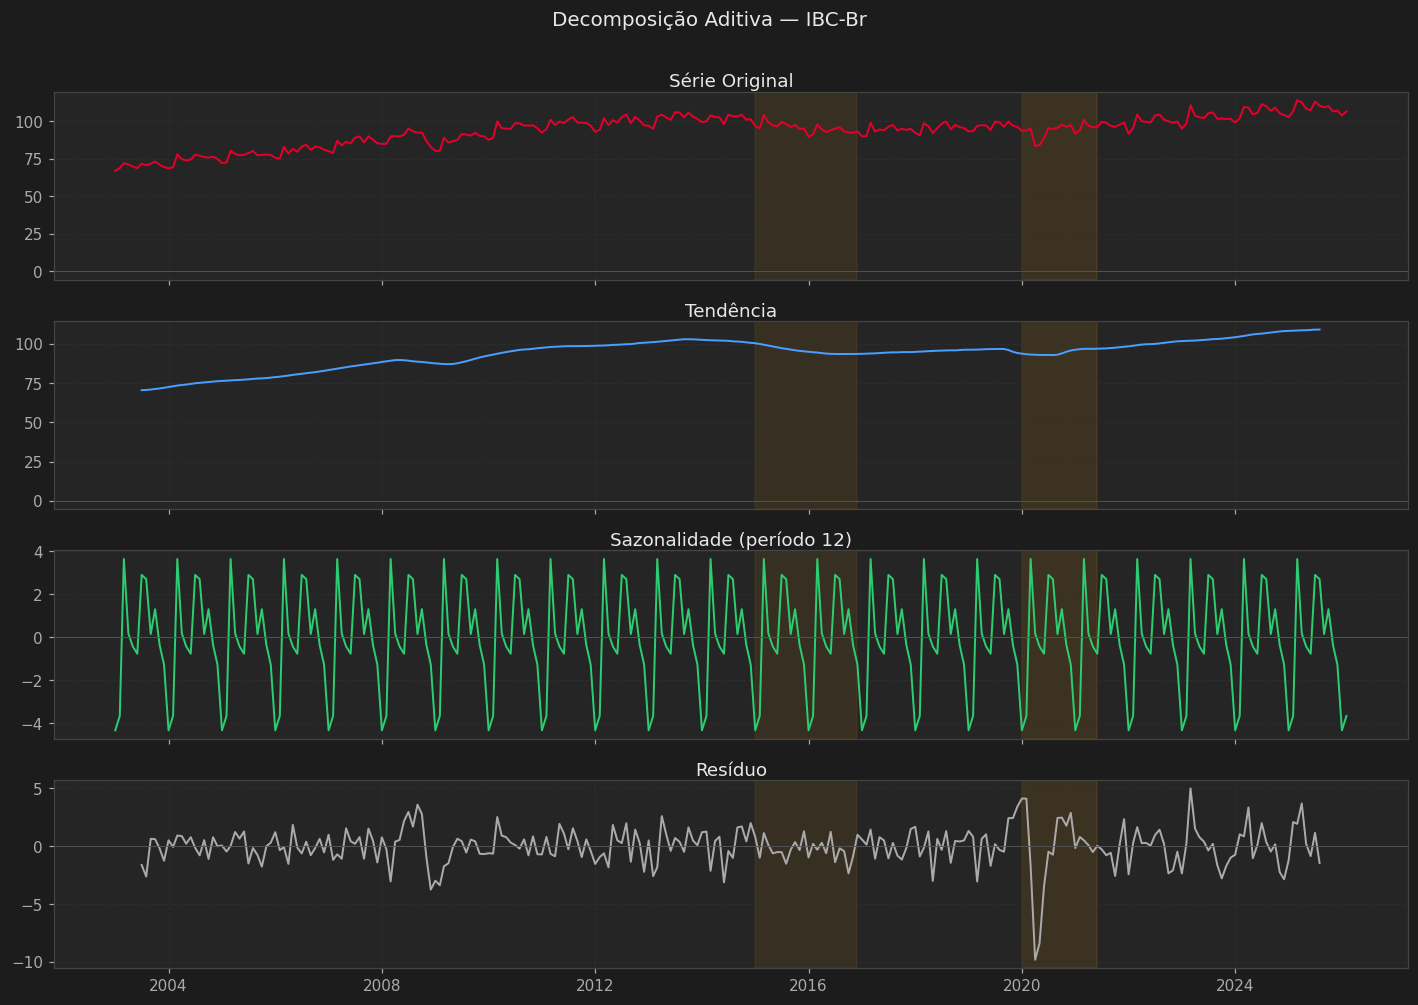

💡 Observe:
   • Tendência: crise 2015-16 visível como queda
   • Sazonalidade: padrão estável a cada 12 meses
   • Resíduo: choque do Covid claramente isolado


In [12]:
# Decomposição aditiva clássica do IBC-Br
decomp = seasonal_decompose(ibc['ibc'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
colors = [RED, BLUE, GREEN, GRAY]
labels = ['Série Original', 'Tendência', 'Sazonalidade (período 12)', 'Resíduo']

for ax, comp, color, label in zip(axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    colors, labels):
    ax.plot(comp, color=color, linewidth=1.3)
    ax.set_title(label, pad=3)
    ax.grid(True)
    ax.axhline(0, color='#555', linewidth=0.6)
    # Sombras
    ax.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2016-12-01'),
               alpha=0.08, color='orange')
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
               alpha=0.1, color=YELLOW)

fig.suptitle('Decomposição Aditiva — IBC-Br', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("💡 Observe:")
print("   • Tendência: crise 2015-16 visível como queda")
print("   • Sazonalidade: padrão estável a cada 12 meses")
print("   • Resíduo: choque do Covid claramente isolado")

### 2.3 · Teste ADF (Augmented Dickey-Fuller)

| Hipótese | Significado |
|---|---|
| **H₀** | Série possui raiz unitária → não-estacionária |
| **H₁** | Série é estacionária |
| **p-value > 0.05** | Não rejeitamos H₀ → série provavelmente não-estacionária |
| **p-value ≤ 0.05** | Rejeitamos H₀ → série estacionária ✓ |


In [13]:
def rodar_adf(serie, nome):
    """Roda o teste ADF e exibe resultados formatados."""
    serie = serie.dropna()
    k = int(np.floor((len(serie) - 1) ** (1/3)))
    res = adfuller(serie, maxlag=k, autolag=None, regression='c')

    conclusao = "✅ Rejeita H₀ → ESTACIONÁRIA" if res[1] < 0.05 else "⚠️  Não rejeita H₀ → RAIZ UNITÁRIA"

    print(f"{'='*50}")
    print(f"ADF — {nome}")
    print(f"{'='*50}")
    print(f"  Estatística ADF : {res[0]:.4f}")
    print(f"  p-value         : {res[1]:.4f}")
    print(f"  Lags usados     : {res[2]}")
    print(f"  Valores críticos:")
    for nivel, valor in res[4].items():
        print(f"    {nivel}: {valor:.4f}")
    print(f"  → {conclusao}")
    print()
    return res[1]

# Testar nível vs estacionarizado
p_nivel  = rodar_adf(ibc['ibc'],             'IBC-Br — Nível')
p_estac  = rodar_adf(ibc['ibc_diff_seas'],   'IBC-Br — Diff + Diff Sazonal + Dummy')

ADF — IBC-Br — Nível
  Estatística ADF : -2.0412
  p-value         : 0.2688
  Lags usados     : 6
  Valores críticos:
    1%: -3.4547
    5%: -2.8723
    10%: -2.5725
  → ⚠️  Não rejeita H₀ → RAIZ UNITÁRIA

ADF — IBC-Br — Diff + Diff Sazonal + Dummy
  Estatística ADF : -7.0412
  p-value         : 0.0000
  Lags usados     : 6
  Valores críticos:
    1%: -3.4566
    5%: -2.8731
    10%: -2.5729
  → ✅ Rejeita H₀ → ESTACIONÁRIA



---
## 🔴 Parte 3 — PACF e Modelos ARIMA/SARIMA

### 3.1 · Autocorrelação Parcial (PACF)

A PACF mede a correlação entre $Y_t$ e $Y_{t-k}$ **após remover o efeito dos lags intermediários**.

**Tabela de identificação:**

| ACF | PACF | Modelo sugerido |
|---|---|---|
| Corte abrupto em $q$ | Decaimento exponencial | **MA($q$)** |
| Decaimento exponencial | Corte abrupto em $p$ | **AR($p$)** |
| Ambas decaem | Ambas decaem | **ARMA($p,q$)** |
| Decaimento muito lento | Pico no lag 1 | **Não estacionário** → diferenciar |


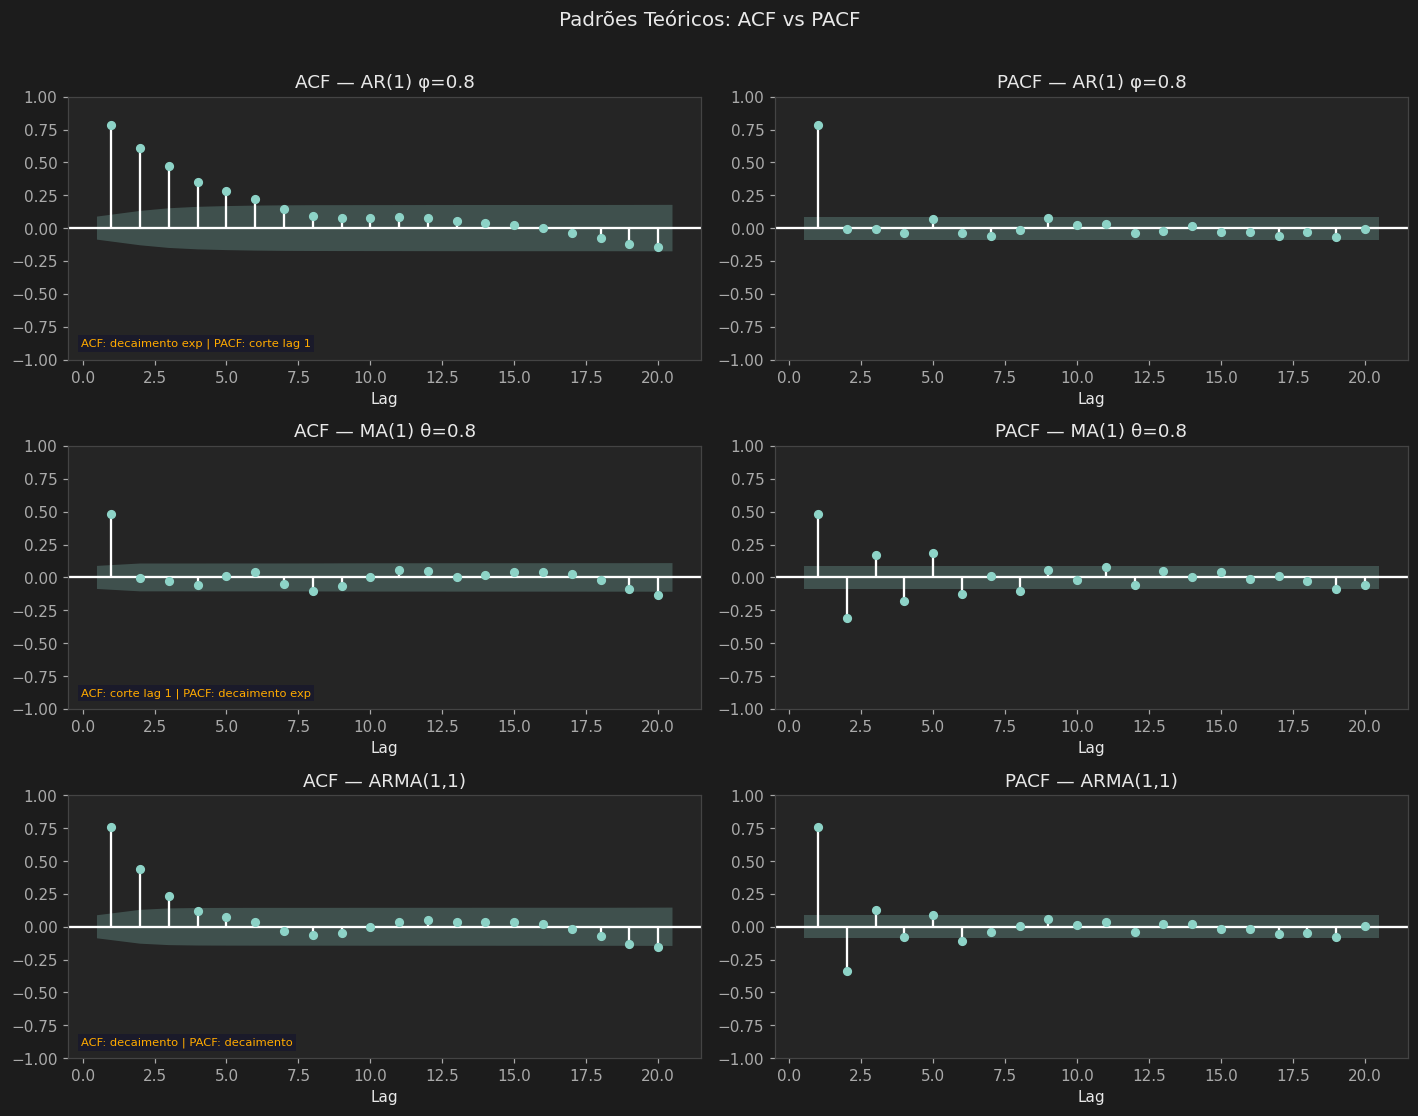

In [14]:
# Padrões teóricos: AR(1), MA(1) e ARMA(1,1)
np.random.seed(42)
n_sim = 500
eps = np.random.normal(0, 1, n_sim)

# AR(1) com phi = 0.8
ar1 = np.zeros(n_sim); ar1[0] = eps[0]
for i in range(1, n_sim): ar1[i] = 0.8 * ar1[i-1] + eps[i]

# MA(1) com theta = 0.8
ma1 = np.array([eps[i] + 0.8 * eps[i-1] for i in range(1, n_sim)])

# ARMA(1,1)
arma11 = np.zeros(n_sim); arma11[0] = eps[0]
for i in range(1, n_sim): arma11[i] = 0.6 * arma11[i-1] + eps[i] + 0.5 * eps[i-1]

processos = [
    (ar1,   'AR(1) φ=0.8',   'ACF: decaimento exp | PACF: corte lag 1'),
    (ma1,   'MA(1) θ=0.8',   'ACF: corte lag 1 | PACF: decaimento exp'),
    (arma11,'ARMA(1,1)',      'ACF: decaimento | PACF: decaimento'),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for row, (serie, nome, dica) in enumerate(processos):
    plot_acf( pd.Series(serie), ax=axes[row,0], lags=20, zero=False,
              title=f'ACF — {nome}')
    plot_pacf(pd.Series(serie), ax=axes[row,1], lags=20, zero=False,
              title=f'PACF — {nome}')
    axes[row,0].set_xlabel('Lag'); axes[row,1].set_xlabel('Lag')
    axes[row,0].text(0.02, 0.05, dica, transform=axes[row,0].transAxes,
                     fontsize=7.5, color=YELLOW,
                     bbox=dict(facecolor='#1a1a2a', edgecolor='none', pad=2))

fig.suptitle('Padrões Teóricos: ACF vs PACF', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

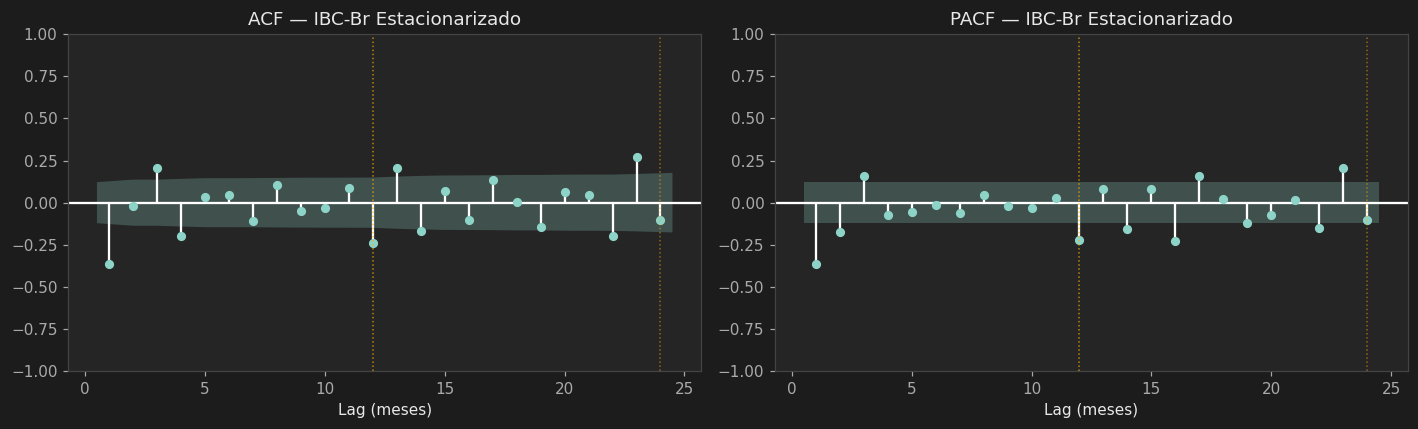

💡 Leitura:
   • ACF: corte após lag 1 → sugere MA(1) na parte não-sazonal (q=1)
   • Pico no lag 12 da ACF → sugere SMA(1) na parte sazonal (Q=1)
   • Candidato inicial: SARIMA(0,1,1)(0,1,1)₁₂


In [15]:
# ACF e PACF do IBC-Br estacionarizado
serie_est = ibc['ibc_diff_seas'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf( serie_est, ax=axes[0], lags=24, zero=False,
          title='ACF — IBC-Br Estacionarizado')
plot_pacf(serie_est, ax=axes[1], lags=24, zero=False,
          title='PACF — IBC-Br Estacionarizado')

for ax in axes:
    ax.set_xlabel('Lag (meses)')
    ax.axvline(12, color=YELLOW, linewidth=1, linestyle=':', alpha=0.7)
    ax.axvline(24, color=YELLOW, linewidth=1, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("💡 Leitura:")
print("   • ACF: corte após lag 1 → sugere MA(1) na parte não-sazonal (q=1)")
print("   • Pico no lag 12 da ACF → sugere SMA(1) na parte sazonal (Q=1)")
print("   • Candidato inicial: SARIMA(0,1,1)(0,1,1)₁₂")

### 3.2 · Modelos AR, MA, ARIMA

**AR($p$)** — valor de hoje depende de $p$ valores passados:
$$Y_t = c + \phi_1 Y_{t-1} + \cdots + \phi_p Y_{t-p} + \varepsilon_t$$

**MA($q$)** — valor de hoje depende de $q$ choques passados:
$$Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

**ARIMA($p$, $d$, $q$)** — combina diferenciação ($d$) com AR e MA.

**SARIMA($p$,$d$,$q$)($P$,$D$,$Q$)$_s$** — extensão sazonal com dois andares de parâmetros:

| Parâmetro | Significado | Como determinar |
|---|---|---|
| $p$, $q$ | Ordens AR/MA não-sazonais | PACF/ACF nos lags 1–11 |
| $d$ | Nº de diferenças regulares | Teste ADF |
| $P$, $Q$ | Ordens AR/MA sazonais | PACF/ACF nos lags 12, 24 |
| $D$ | Nº de diferenças sazonais | Inspeção da ACF sazonal |
| $s$ | Período sazonal | Dados (mensal → $s=12$) |

Para o IBC-Br: $d=1$, $D=1$, $s=12$ → candidato: **SARIMA(0,1,1)(0,1,1)₁₂**


---
## 🔴 Parte 4 — Modelagem na Prática

### 4.1 · AutoARIMA — Seleção Automática

O algoritmo **Hyndman-Khandakar** automatiza o procedimento Box-Jenkins:
1. Determina $d$ e $D$ automaticamente via testes ADF/KPSS
2. Parte de um modelo inicial e busca modelos vizinhos (±1 em $p$, $q$, $P$, $Q$)
3. Seleciona o modelo com menor **AICc**
4. Verifica o diagnóstico dos resíduos


In [16]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

# Preparar dados no formato Nixtla (unique_id, ds, y)
ibcbr_df = ibc[['ibc']].reset_index()
ibcbr_df.columns = ['ds', 'y']
ibcbr_df['unique_id'] = 'ibcbr'

# Ajustar AutoARIMA com sazonalidade mensal
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='MS',
    n_jobs=1,
)
sf.fit(df=ibcbr_df)

# Ver modelo selecionado
modelo = sf.fitted_[0, 0].model_
print("Modelo selecionado pelo AutoARIMA:")
print(f"  Ordem: ARIMA{modelo.get('arma', 'N/A')}")
print(f"  AIC:   {modelo.get('aic', 'N/A'):.2f}")

Modelo selecionado pelo AutoARIMA:
  Ordem: ARIMA(3, 3, 1, 1, 12, 1, 1)
  AIC:   1091.73


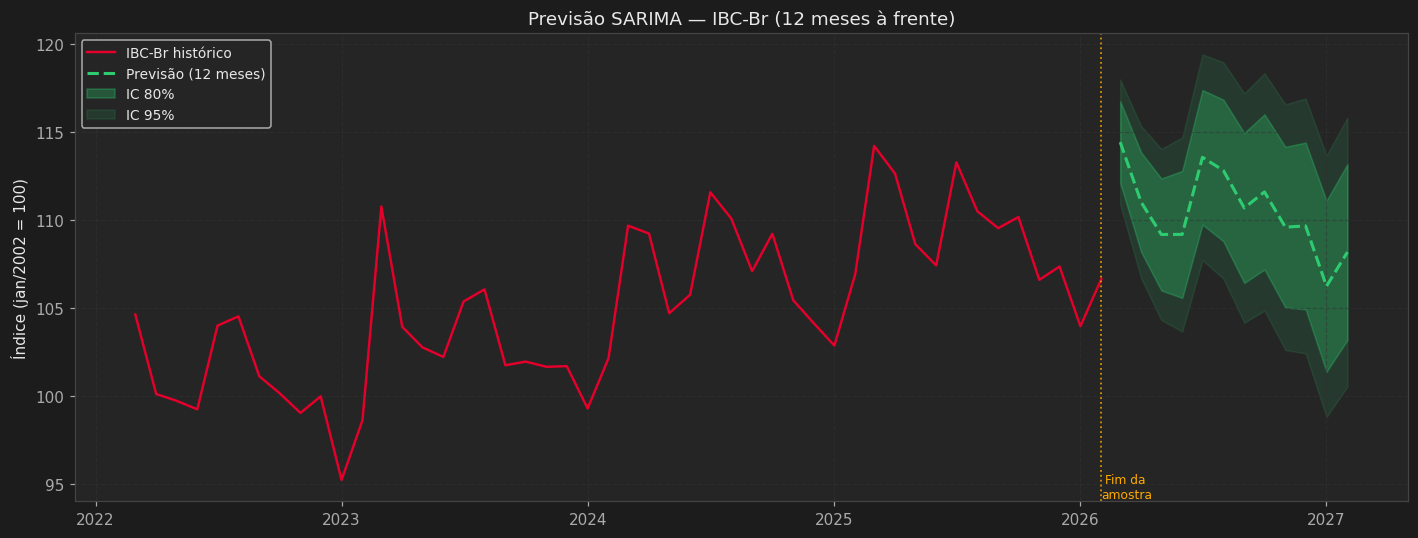

In [17]:
# Previsão 12 meses à frente com intervalos de confiança
previsao = sf.predict(h=12, level=[80, 95])

fig, ax = plt.subplots(figsize=(13, 5))

# Histórico (últimos 4 anos)
hist = ibc['ibc'].iloc[-48:]
ax.plot(hist.index, hist.values, color=RED, linewidth=1.6, label='IBC-Br histórico')

# Previsão
ax.plot(previsao['ds'], previsao['AutoARIMA'],
        color=GREEN, linewidth=2, linestyle='--', label='Previsão (12 meses)')

# Intervalos de confiança
ax.fill_between(previsao['ds'],
    previsao['AutoARIMA-lo-80'], previsao['AutoARIMA-hi-80'],
    alpha=0.3, color=GREEN, label='IC 80%')
ax.fill_between(previsao['ds'],
    previsao['AutoARIMA-lo-95'], previsao['AutoARIMA-hi-95'],
    alpha=0.12, color=GREEN, label='IC 95%')

ax.axvline(ibc.index[-1], color=YELLOW, linewidth=1.2, linestyle=':', alpha=0.8)
ax.text(ibc.index[-1], ax.get_ylim()[0], ' Fim da\namostra',
        color=YELLOW, fontsize=8, va='bottom')

ax.set_title('Previsão SARIMA — IBC-Br (12 meses à frente)')
ax.set_ylabel('Índice (jan/2002 = 100)')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

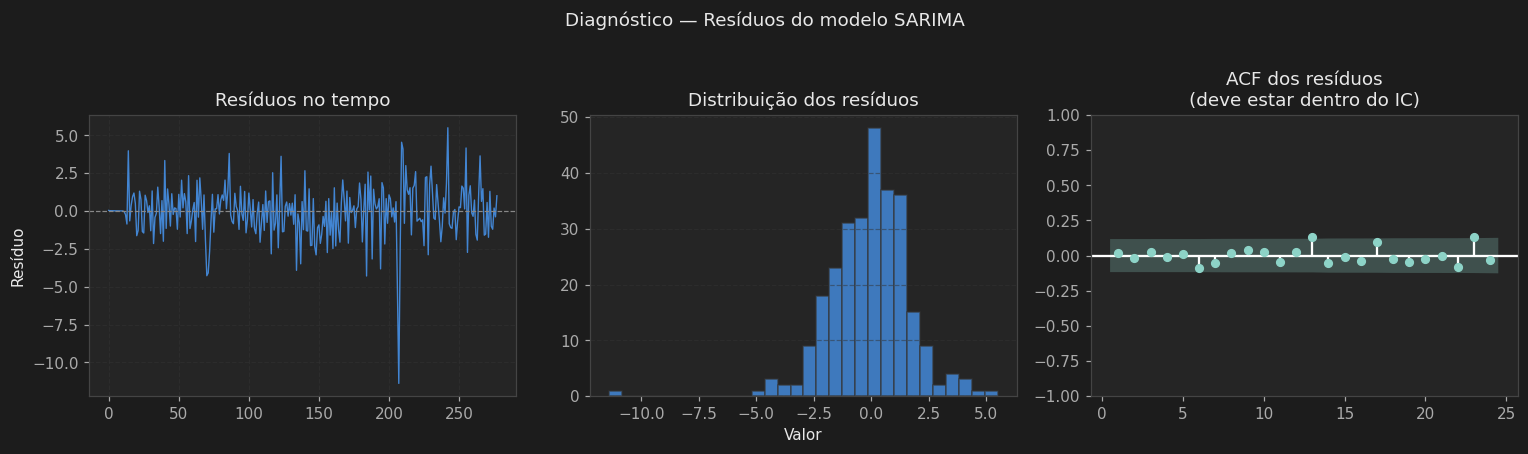

✅ Se a ACF dos resíduos estiver dentro do IC → modelo bem ajustado!


In [18]:
# Diagnóstico dos resíduos
residuos = pd.Series(modelo.get('residuals', []))

if len(residuos) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Resíduos no tempo
    axes[0].plot(residuos.values, color=BLUE, linewidth=0.9, alpha=0.8)
    axes[0].axhline(0, color='#888', linestyle='--', linewidth=0.8)
    axes[0].set_title('Resíduos no tempo')
    axes[0].set_ylabel('Resíduo'); axes[0].grid(True)

    # Histograma
    axes[1].hist(residuos, bins=30, color=BLUE, alpha=0.7, edgecolor='#333')
    axes[1].set_title('Distribuição dos resíduos')
    axes[1].set_xlabel('Valor'); axes[1].grid(True, axis='y')

    # ACF dos resíduos — deve ser ruído branco
    plot_acf(residuos, ax=axes[2], lags=24, zero=False,
             title='ACF dos resíduos\n(deve estar dentro do IC)')

    plt.suptitle('Diagnóstico — Resíduos do modelo SARIMA', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print("✅ Se a ACF dos resíduos estiver dentro do IC → modelo bem ajustado!")
else:
    print("(Resíduos não disponíveis nesta versão do statsforecast)")

---
## 🏋️ Exercício Proposto

Escolha uma série do Banco Central e aplique o pipeline completo:

1. Carregue a série via `bcb_serie()`
2. Plote a série e a ACF — identifique tendência e sazonalidade
3. Aplique as diferenças necessárias para estacionarizar
4. Verifique com o teste ADF
5. Use a tabela ACF/PACF para propor um modelo SARIMA manualmente
6. Compare com o AutoARIMA — chegaram ao mesmo modelo?
7. Avalie o diagnóstico dos resíduos

**Sugestões de séries:**

| Série | Código BCB | Frequência |
|---|---|---|
| Taxa Selic | 11 | Diária |
| IPCA | 433 | Mensal |
| Taxa de desemprego | 24369 | Mensal |
| Câmbio USD/BRL | 1 | Diária |
| Produção industrial | 21859 | Mensal |


In [19]:
# Espaço para o exercício — complete aqui!

# Escolha o código da série BCB e execute
CODIGO = None  # ex: 433 para IPCA

if CODIGO:
    minha_serie = bcb_serie(CODIGO, start='2003-01-01')
    col = minha_serie.columns[0]
    minha_serie.index = pd.to_datetime(minha_serie.index)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(minha_serie.index, minha_serie[col], color=RED, linewidth=1.4)
    axes[0].set_title(f'Série BCB {CODIGO}'); axes[0].grid(True)
    plot_acf(minha_serie[col].dropna(), ax=axes[1], lags=24, zero=False,
             title='ACF — Nível')
    plt.tight_layout(); plt.show()
else:
    print("⬆️  Defina o CODIGO da série acima e execute novamente!")
    print()
    print("Sugestões:")
    print("  CODIGO = 433    # IPCA mensal")
    print("  CODIGO = 1      # Câmbio USD/BRL diário")
    print("  CODIGO = 24369  # Taxa de desemprego mensal")
    print("  CODIGO = 11     # Taxa Selic diária")
    print("  CODIGO = 21859  # Produção industrial mensal")


⬆️  Defina o CODIGO da série acima e execute novamente!

Sugestões:
  CODIGO = 433    # IPCA mensal
  CODIGO = 1      # Câmbio USD/BRL diário
  CODIGO = 24369  # Taxa de desemprego mensal
  CODIGO = 11     # Taxa Selic diária
  CODIGO = 21859  # Produção industrial mensal


---
## 📖 Referências

- **Forecasting: Principles and Practice** (3ª ed.) — Hyndman & Athanasopoulos  
  🔗 https://otexts.com/fpp3/

- **Material do curso** — PADS Insper 2026  
  🔗 https://padsinsper.github.io/202632-fa/

- **python-bcb** — acesso à API do Banco Central  
  🔗 https://wilsonfreitas.github.io/python-bcb/

- **statsforecast** — AutoARIMA e modelos de alta performance  
  🔗 https://nixtlaverse.nixtla.io/statsforecast/
